# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [56]:
# Research question:
# Do FlyRank pages fall into a small number of clear types?
# And can we use the page type, staleness, and CTR
# to decide which pages an editor should review first?

# Goal:
# Help an editor choose a small number of pages to review each week.
# This is not predicting future traffic.
# It is only using the current data to decide what to review first.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [57]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

df = pd.read_csv("/content/content_refresh_anonymized.csv")

print(f"Pages: {len(df):,}")
print(f"Clients: {df['client_id'].nunique()}")

print("\nContent types:")
print(df["content_type"].value_counts())

Pages: 30,000
Clients: 32

Content types:
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [58]:
from sklearn.cluster import KMeans

# Features used to group pages
FEATURE_COLS = [
    "impressions_90d",
    "days_since_last_update"
]

# Split clients: 80% for training, 20% for testing
clients = sorted(df["client_id"].unique())

rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(clients)

cut = int(len(clients) * 0.8)

train_clients = set(clients[:cut])
test_clients = set(clients[cut:])

train_mask = df["client_id"].isin(train_clients)
test_mask = df["client_id"].isin(test_clients)

# Create 4 archetypes
kmeans = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=10
)

# Learn the groups using only training clients
kmeans.fit(df.loc[train_mask, FEATURE_COLS])

# Give every page an archetype
df["archetype"] = kmeans.predict(df[FEATURE_COLS])

print("Features:", FEATURE_COLS)
print("Archetypes created:", df["archetype"].nunique())

Features: ['impressions_90d', 'days_since_last_update']
Archetypes created: 4


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [59]:
# Simple baseline:
# group pages using freshness + impressions

df["baseline_group"] = (
    df["freshness_tier"].astype(str)
    + "|"
    + df["impression_tier"].astype(str)
)

baseline_codes = {
    group: i
    for i, group in enumerate(sorted(df["baseline_group"].unique()))
}

df["baseline_cluster"] = df["baseline_group"].map(baseline_codes)

print("Baseline groups:", df["baseline_cluster"].nunique())

Baseline groups: 16


## 5. Limitations

*What this work cannot claim.*

In [60]:
# These columns must NOT be used to create the clusters

forbidden = {
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "content_id",
    "client_id"
}

used_forbidden = forbidden.intersection(FEATURE_COLS)

if used_forbidden:
    print("WARNING: possible leakage:", used_forbidden)
else:
    print("Leakage check passed.")
    print("Only these features are used:", FEATURE_COLS)

Leakage check passed.
Only these features are used: ['impressions_90d', 'days_since_last_update']


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [61]:
from sklearn.metrics import silhouette_score

# Use only the unseen 20% of clients
test_X = df.loc[test_mask, FEATURE_COLS]

kmeans_labels = df.loc[test_mask, "archetype"]
baseline_labels = df.loc[test_mask, "baseline_cluster"]

# Use up to 5,000 pages to make the calculation faster
sample_size = min(5000, len(test_X))

sample_idx = rng.choice(
    len(test_X),
    size=sample_size,
    replace=False
)

X_sample = test_X.to_numpy()[sample_idx]

results = pd.DataFrame([
    {
        "method": "baseline",
        "silhouette": silhouette_score(
            X_sample,
            baseline_labels.to_numpy()[sample_idx]
        )
    },
    {
        "method": "kmeans",
        "silhouette": silhouette_score(
            X_sample,
            kmeans_labels.to_numpy()[sample_idx]
        )
    }
])

print("Comparison on unseen clients:")
print(results.round(3))
print()
print("Higher silhouette = clearer separation between groups.")

Comparison on unseen clients:
     method  silhouette
0  baseline      -0.128
1    kmeans       0.840

Higher silhouette = clearer separation between groups.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [62]:
# Create the priority/action

stale = df["days_since_last_update"] >= 31
visible = df["impressions_90d"] >= 500

median_ctr = df.loc[visible, "ctr"].median()
underperforming = df["ctr"] < median_ctr

df["action"] = "monitor"

df.loc[
    stale & visible & underperforming,
    "action"
] = "refresh"

df.loc[
    ~stale & visible & underperforming,
    "action"
] = "investigate"

print("Actions created:")
print(df["action"].value_counts())

Actions created:
action
monitor        21748
investigate     4722
refresh         3530
Name: count, dtype: int64


In [63]:
order = {
    "refresh": 0,
    "investigate": 1,
    "monitor": 2
}

df["tier"] = df["action"].map(order)

ranked_queue = (
    df.sort_values(
        ["tier", "impressions_90d"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

ranked_queue["rank"] = ranked_queue.index + 1

print("Top 10 pages:")
print(
    ranked_queue[
        [
            "rank",
            "action",
            "archetype",
            "impressions_90d",
            "ctr",
            "days_since_last_update"
        ]
    ].head(10)
)

Top 10 pages:
   rank   action  archetype  impressions_90d   ctr  days_since_last_update
0     1  refresh          3           517715  0.14                     104
1     2  refresh          3           497727  0.10                      48
2     3  refresh          3           309910  0.16                     104
3     4  refresh          3           295097  0.05                     104
4     5  refresh          3           286608  0.06                     104
5     6  refresh          3           233561  0.06                     104
6     7  refresh          1           208678  0.00                     104
7     8  refresh          1           205915  0.14                     104
8     9  refresh          1           201111  0.11                     104
9    10  refresh          1           181574  0.16                     104


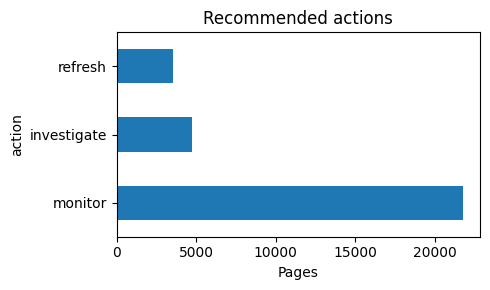

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3))

df["action"].value_counts().plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Pages")
ax.set_title("Recommended actions")

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
